In [27]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from numpy import pi, random
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.result import marginal_counts
import numpy as np
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

<IPython.core.display.Latex object>

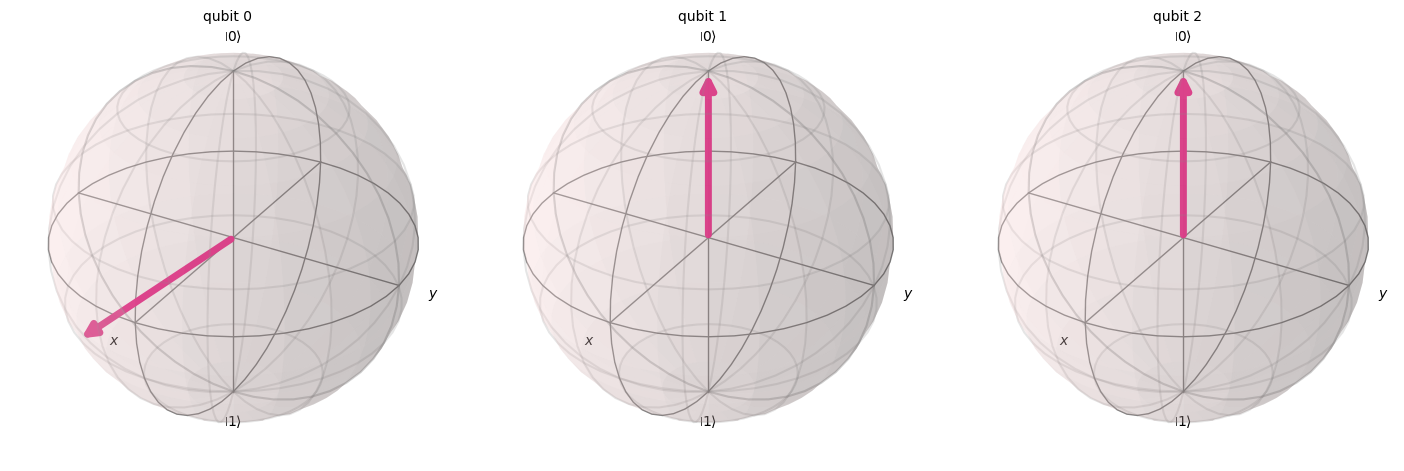

In [171]:

# generamos 3 ángulos al azar, para posicionarnos en la esfera de Bloch en una posición aleatoria
theta = random.random() * 2 * pi
phi = random.random() * 2 * pi
lam = random.random() * 2 * pi


qr_alicia = QuantumRegister(2, name='alicia')  # dos qubits de Alicia
qr_bob = QuantumRegister(1, name='bob')        # un qubit de Bob
crz = ClassicalRegister(1, name='crz')         # 2 bits clasicos
crx = ClassicalRegister(1, name='crx')         # en 2 diferentes registros

circuitoTest0= QuantumCircuit(qr_alicia, qr_bob, crz, crx)
circuitoTest1= QuantumCircuit(qr_alicia, qr_bob, crz, crx)
circuitoTest2= QuantumCircuit(qr_alicia, qr_bob, crz, crx)
circuitoTest3= QuantumCircuit(qr_alicia, qr_bob, crz, crx)


circuitoTest0.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios
circuitoTest1.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios
circuitoTest2.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios
circuitoTest3.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios

psi_state = Statevector(circuitoTest1)                             # obtenemos el vector de estado para visualizarlo

display(psi_state.draw('latex', prefix="|\\psi\\rangle ="))    # mostrar en notación de Dirac

plot_bloch_multivector(psi_state)                              # mostrar en esfera de Bloch

    

In [172]:
def crear_estado_bell(circ, b, c, b_s):#|cb>/|q2q1>
    match b_s:
        case 0:
            ##CNOT(HxI)|00>:
            circ.h(c)       # poner el qubit c en el estado |+>
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case 1:   
            ##CNOT(HxI)|01>:
            circ.x(b)
            circ.h(c)       # poner el qubit c en el estado |+>
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case 2:
            ##CNOT(HxI)|10>:
            circ.x(c)
            circ.h(c)       # poner el qubit c en el estado |->
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case 3:
            
            ##CNOT(HxI)|11>:
            circ.x(c)
            circ.x(b)
            circ.h(c)       # poner el qubit c en el estado |->
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case _:
            ##CNOT(HxI)|00>:
            circ.h(c)       # poner el qubit c en el estado |+>
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
            
def compuertas_alicia(circ, psi, a):
    circ.barrier()
    circ.cx(psi, a)
    circ.h(psi)

def mediciones_y_envio(circ, psi, a):
    circ.barrier()
    circ.measure(psi, 0)
    circ.measure(a, 1)

def decodificacion_bob(circ,b_s):
    match b_s:
        case 0:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
           
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')

        case 1:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
            circ.x(qr_bob[0])
            
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')

        case 2:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
            circ.z(qr_bob[0])
            
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')
        case 3:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
            circ.x(qr_bob[0])
            circ.z(qr_bob[0])
            
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')



def teleportacion(circ,bell_state):
    
    crear_estado_bell(circ, 1, 2, bell_state)   # circuito, índice qubit b, índice qubit c, estado de bell deseado
    compuertas_alicia(circ, 0, 1)
    mediciones_y_envio(circ, 0, 1)
    decodificacion_bob(circ,bell_state)

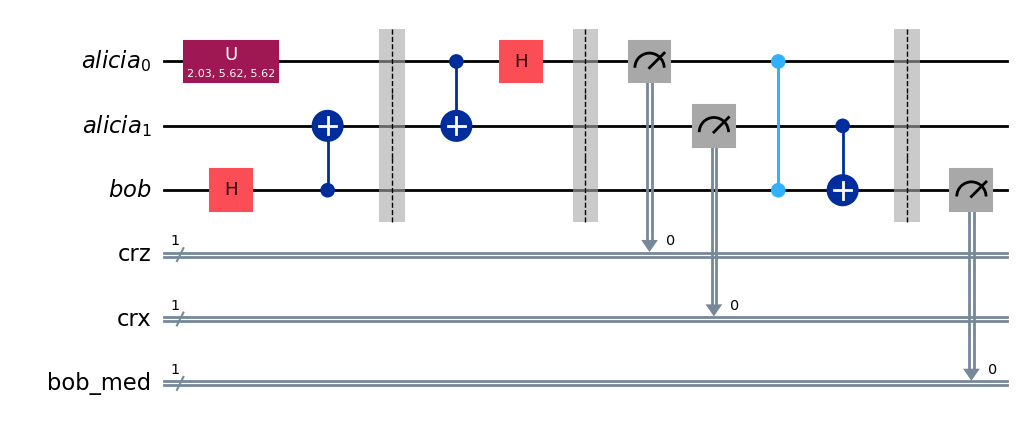

In [173]:

teleportacion(circuitoTest0,0)
circuitoTest0.draw('mpl')


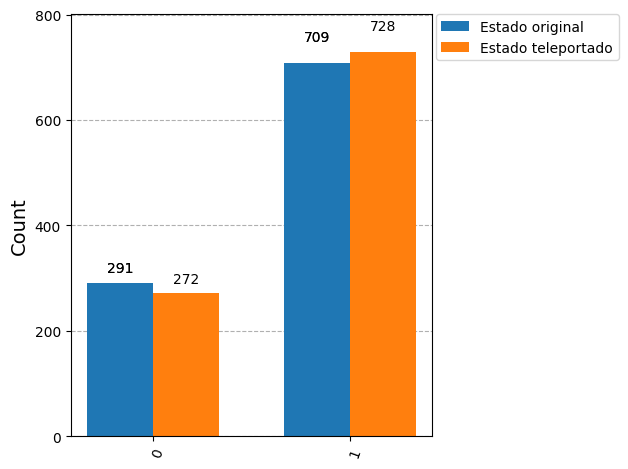

In [174]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest0,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)

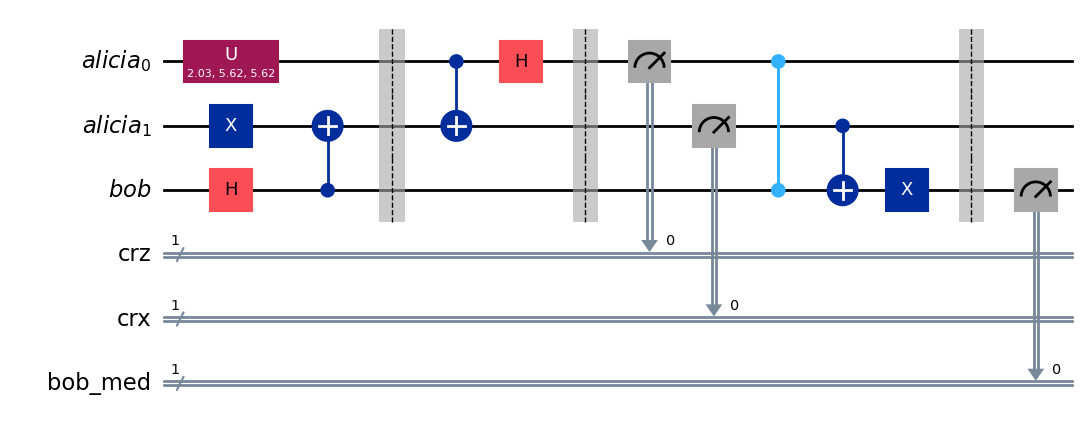

In [175]:
teleportacion(circuitoTest1,1)
circuitoTest1.draw('mpl')


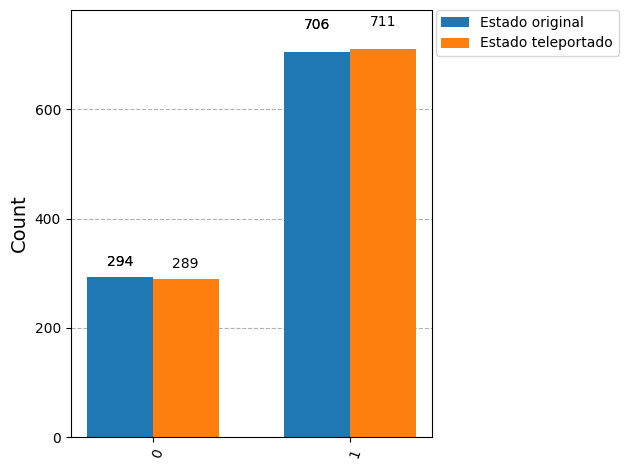

In [176]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest1,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)

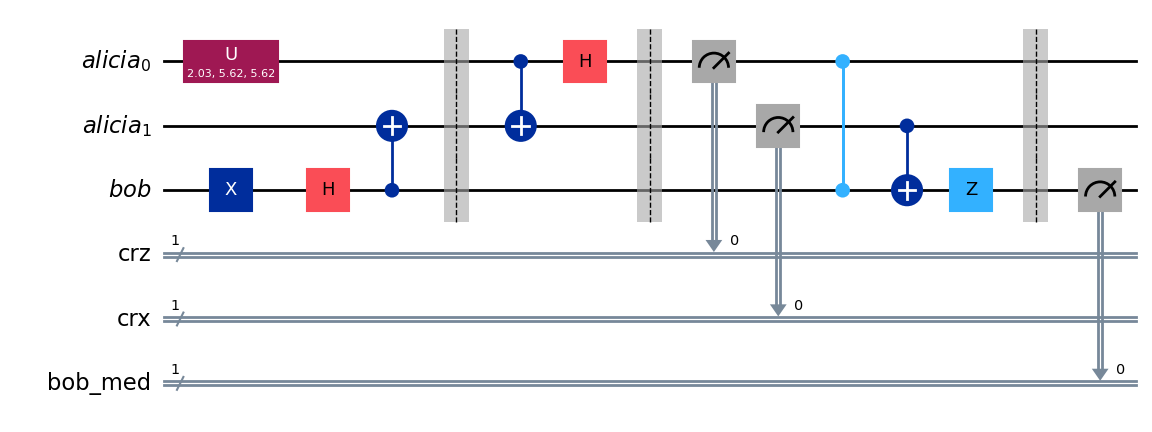

In [177]:
teleportacion(circuitoTest2,2)
circuitoTest2.draw('mpl')


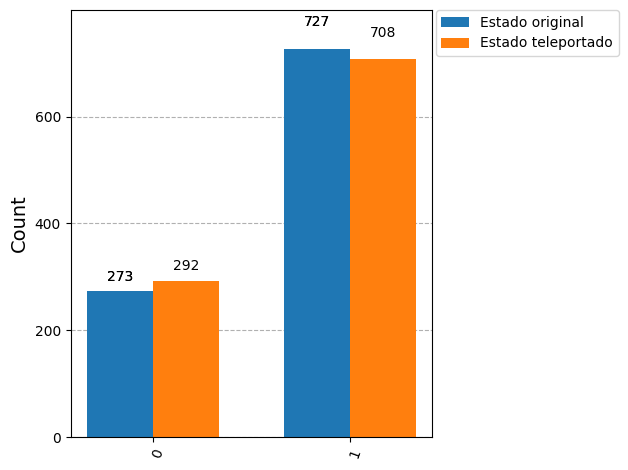

In [178]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest2,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)

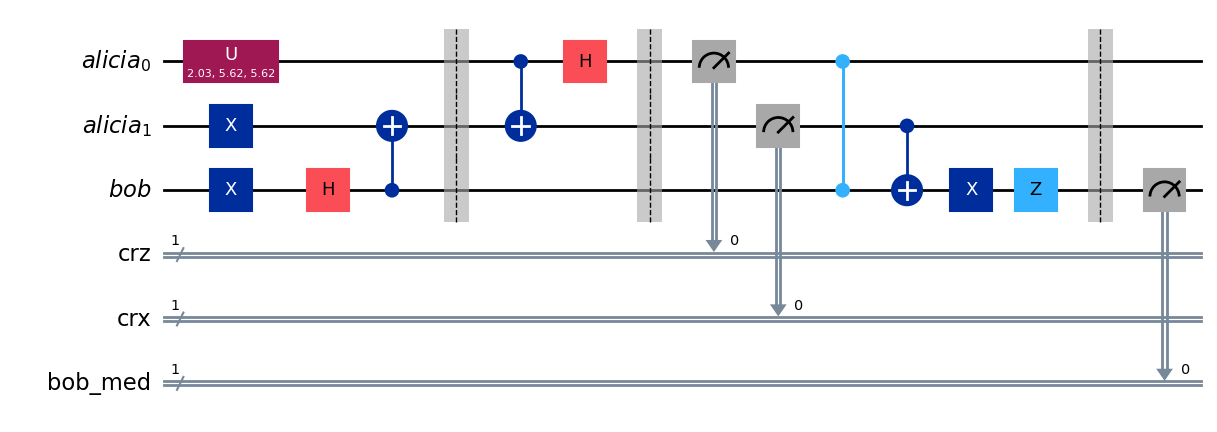

In [179]:
teleportacion(circuitoTest3,3)
circuitoTest3.draw('mpl')


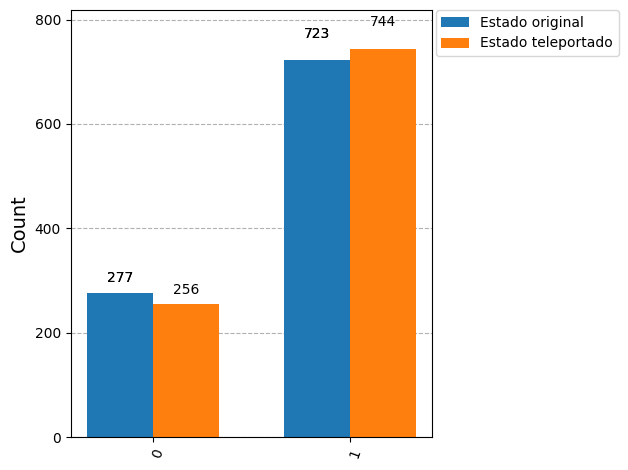

In [180]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest3,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)